# 文件: chart_20_1.py

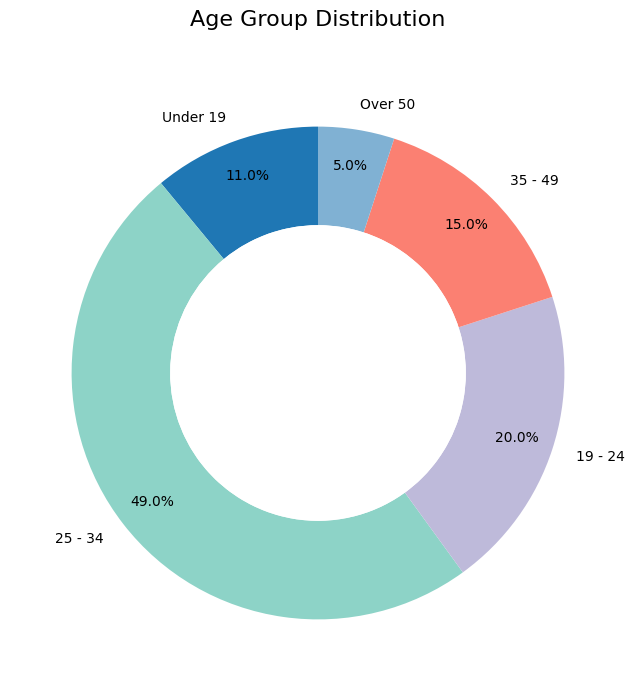

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
age_groups = ["Under 19", "25 - 34", "19 - 24", "35 - 49", "Over 50"]
percentages = [11, 49, 20, 15, 5]
colors = ["#1f77b4", "#8dd3c7", "#bebada", "#fb8072", "#80b1d3"]  # Custom colors, can be adjusted

# Create a donut chart
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    percentages,
    labels=age_groups,
    autopct="%1.1f%%",  # Display percentage format
    startangle=90,
    colors=colors,
    pctdistance=0.85,  # Distance of percentage labels from the center
    wedgeprops={"width": 0.4},  # Width of the donut
)

# Add a center circle (to make the donut more obvious)
centre_circle = plt.Circle((0, 0), 0.6, color="black", fc="white", linewidth=0)
ax.add_artist(centre_circle)

# Set the title
ax.set_title("Age Group Distribution", fontsize=16, y=1.05)

# Display the chart
plt.show()

# 文件: chart_20_2.py

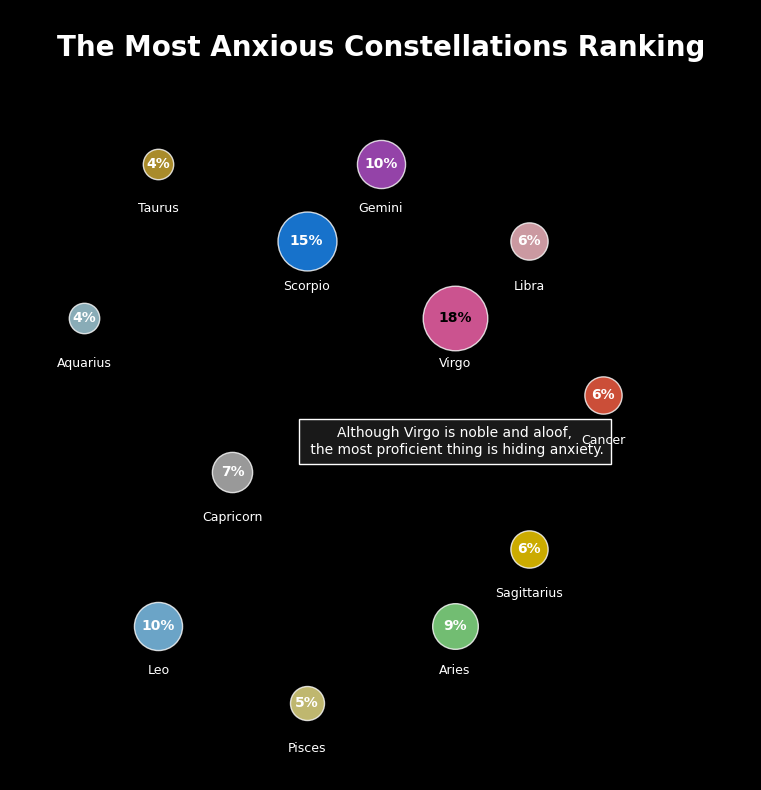

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
constellations = [
    "Taurus", "Aquarius", "Capricorn", "Leo", "Pisces", "Aries", "Sagittarius", "Cancer",
    "Libra", "Gemini", "Virgo", "Scorpio"
]
percentages = [4, 4, 7, 10, 5, 9, 6, 6, 6, 10, 18, 15]
# Manually set the coordinates of each constellation for layout convenience (can be fine - tuned according to the design)
coords = [
    (0.2, 0.8), (0.1, 0.6), (0.3, 0.4), (0.2, 0.2), (0.4, 0.1), (0.6, 0.2),
    (0.7, 0.3), (0.8, 0.5), (0.7, 0.7), (0.5, 0.8), (0.6, 0.6), (0.4, 0.7)
]
# Corresponding bubble colors (example color scheme, can be adjusted by yourself)
colors = [
    "#D4AF37", "#ADD8E6", "#C0C0C0", "#87CEFA", "#F0E68C", "#90EE90",
    "#FFD700", "#FF6347", "#FFC0CB", "#BA55D3", "#FF69B4", "#1E90FF"
]
# Special annotation text for Virgo
virgo_text = "Although Virgo is noble and aloof,\n the most proficient thing is hiding anxiety."

# Create a canvas
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# Hide the axes
ax.set_xticks([])
ax.set_yticks([])

# Draw bubbles + annotations
for constellation, p, (x, y), color in zip(constellations, percentages, coords, colors):
    # Draw bubbles (simulated by scatter plot)
    ax.scatter(
        x, y, 
        s=p * 120,  # Bubble size is related to the anxiety percentage
        c=color, 
        alpha=0.8,
        edgecolors='white', 
        linewidths=1
    )
    # Draw the percentage text
    text_color = 'white' if p != 18 else 'black'  # Reverse the text color for Virgo
    ax.text(
        x, y, 
        f"{p}%", 
        ha='center', 
        va='center', 
        fontsize=10, 
        color=text_color, 
        fontweight='bold'
    )
    # Draw the constellation name
    ax.text(
        x, y - 0.05, 
        constellation, 
        ha='center', 
        va='top', 
        fontsize=9, 
        color='white'
    )

# Special description text for Virgo
virgo_x, virgo_y = coords[constellations.index("Virgo")]
ax.text(
    virgo_x, virgo_y - 0.18, 
    virgo_text, 
    ha='center', 
    va='bottom', 
    fontsize=10, 
    color='white', 
    linespacing=1.2,
    # Fix: Change the CSS color format to RGBA tuple format
    bbox=dict(facecolor=(1, 1, 1, 0.1), edgecolor='white', pad=5)
)

# Add a title
ax.text(
    0.5, 0.95, 
    "The Most Anxious Constellations Ranking", 
    ha='center', 
    va='center', 
    fontsize=20, 
    color='white', 
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 文件: chart_20_3.py

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_2320\2051298556.py:85: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=cm.get_cmap('Blues_r'), alpha=0.3


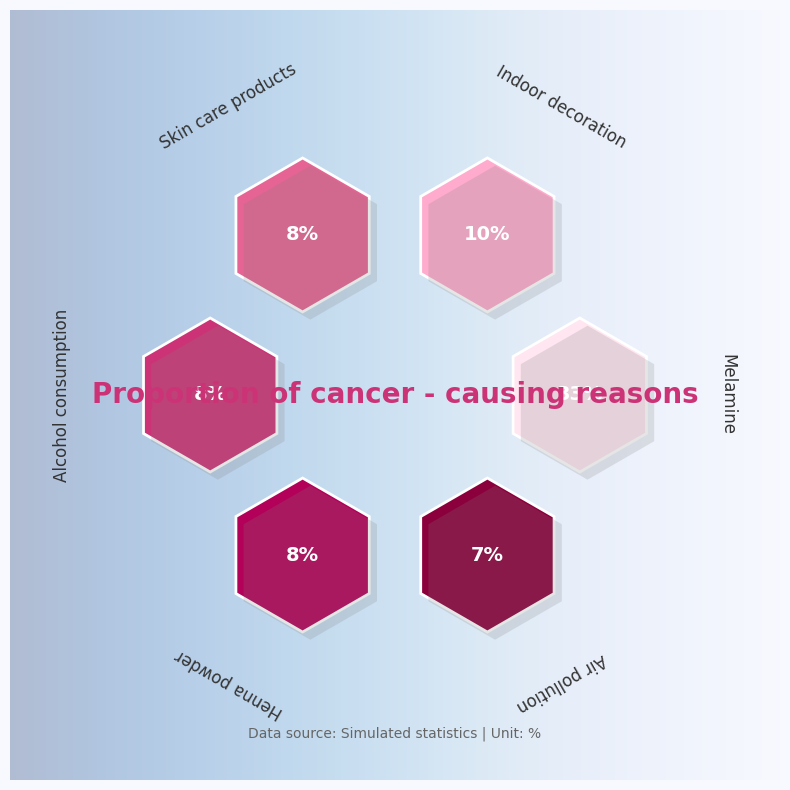

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import numpy as np
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

# ======================== 1. Data and basic configuration ========================
labels = ["Melamine", "Indoor decoration", "Skin care products", "Alcohol consumption", "Henna powder", "Air pollution"]
sizes = [33, 10, 8, 8, 8, 7]

# Coordinates for hexagonal ring distribution (convert polar coordinates to Cartesian coordinates)
theta = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
radius = 1.2  # Control the radius of the hexagonal ring
x = radius * np.cos(theta)
y = radius * np.sin(theta)

# Custom gradient color palette (from light pink to dark pink)
cmap = LinearSegmentedColormap.from_list(
    'pink_cmap',
    ['#FFE6F0', '#FFABCD', '#E66493', '#CC3377', '#B30059', '#8B003C'],
    N=len(labels)
)

# ======================== 2. Initialize the canvas and axes ========================
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#F8F8FF')  # Light blue background
ax.set_aspect('equal')
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axis('off')  # Hide the axes

# ======================== 3. Draw 3D hexagons (with shadows and gradients) ========================
for i in range(len(labels)):
    # Main hexagon (gradient fill)
    hex_main = RegularPolygon(
        (x[i], y[i]), numVertices=6, radius=0.5,
        facecolor=cmap(i), edgecolor='white', linewidth=2
    )
    ax.add_patch(hex_main)

    # Shadow hexagon (simulate 3D effect)
    hex_shadow = RegularPolygon(
        (x[i] + 0.05, y[i] - 0.05), numVertices=6, radius=0.5,
        facecolor='gray', alpha=0.2, edgecolor='none'
    )
    ax.add_patch(hex_shadow)

    # Draw the percentage number (centered, bold)
    ax.text(
        x[i], y[i], f"{sizes[i]}%",
        ha='center', va='center',
        fontsize=14, fontweight='bold',
        color='white'
    )

    # Draw the label text (surrounding layout, adjust the angle)
    text_angle = np.rad2deg(theta[i]) - 90  # Adjust the text angle for the hexagon
    ax.text(
        x[i] * 1.8, y[i] * 1.8, labels[i],
        ha='center', va='center',
        fontsize=12, color='#333333',
        rotation=text_angle
    )

# ======================== 4. Add title and decoration ========================
# Center title
ax.text(
    0, 0, "Proportion of cancer - causing reasons",
    ha='center', va='center',
    fontsize=20, fontweight='bold',
    color='#CC3377'
)

# Bottom description
ax.text(
    0, -2.2, "Data source: Simulated statistics | Unit: %",
    ha='center', va='center',
    fontsize=10, color='#666666',
)

# Gradient background (diffusing from the center)
gradient = np.linspace(0, 1, 256).reshape(1, -1)
gradient_img = np.tile(gradient, (256, 1))
ax.imshow(
    gradient_img, extent=(-2.5, 2.5, -2.5, 2.5),
    cmap=cm.get_cmap('Blues_r'), alpha=0.3
)

plt.tight_layout()
plt.show()

# 文件: chart_20_4.py

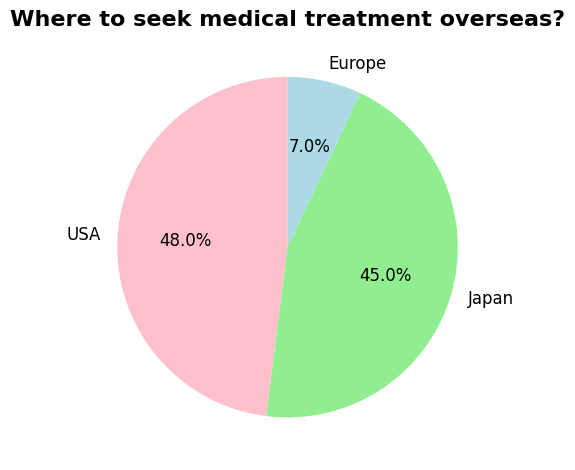

In [4]:
import matplotlib.pyplot as plt

# Data
countries = ["USA", "Japan", "Europe"]
percentages = [48, 45, 7]  
colors = ["pink", "lightgreen", "lightblue"]  

# Create a pie chart
plt.pie(
    percentages, 
    labels=countries, 
    colors=colors, 
    autopct="%1.1f%%",  # Display percentages
    startangle=90,      # Starting angle
    textprops={"fontsize": 12}
)

# Add a title
plt.title("Where to seek medical treatment overseas?", fontsize=16, fontweight="bold")

# Adjust the layout (to avoid label crowding)
plt.tight_layout()

# Display the chart
plt.show()

# 文件: chart_20_5.py

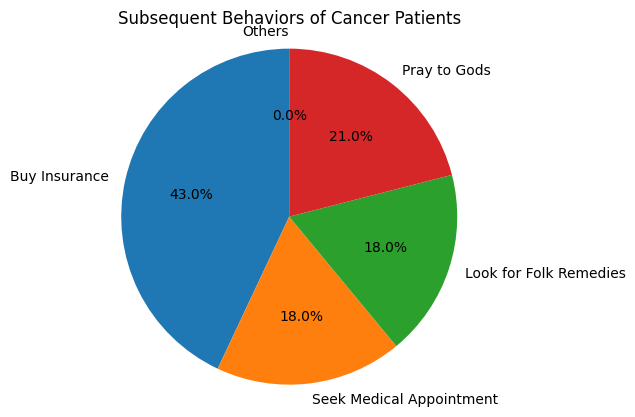

In [5]:
import matplotlib.pyplot as plt

# Data
labels = ['Buy Insurance', 'Seek Medical Appointment', 'Look for Folk Remedies', 'Pray to Gods', 'Others']
sizes = [43, 18, 18, 21, 0]  # Proportions of each part, the sum is 100, can be adjusted as needed
colors = ['#FFA07A', '#90EE90', '#FFC0CB', '#87CEFA', '#D3D3D3']  # Colors of each part, can be customized

# Draw a pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.axis('equal')  # Ensure the pie chart is a perfect circle

# Add a title
plt.title('Subsequent Behaviors of Cancer Patients')

# Display the chart
plt.show()

# 文件: chart_20_6.py

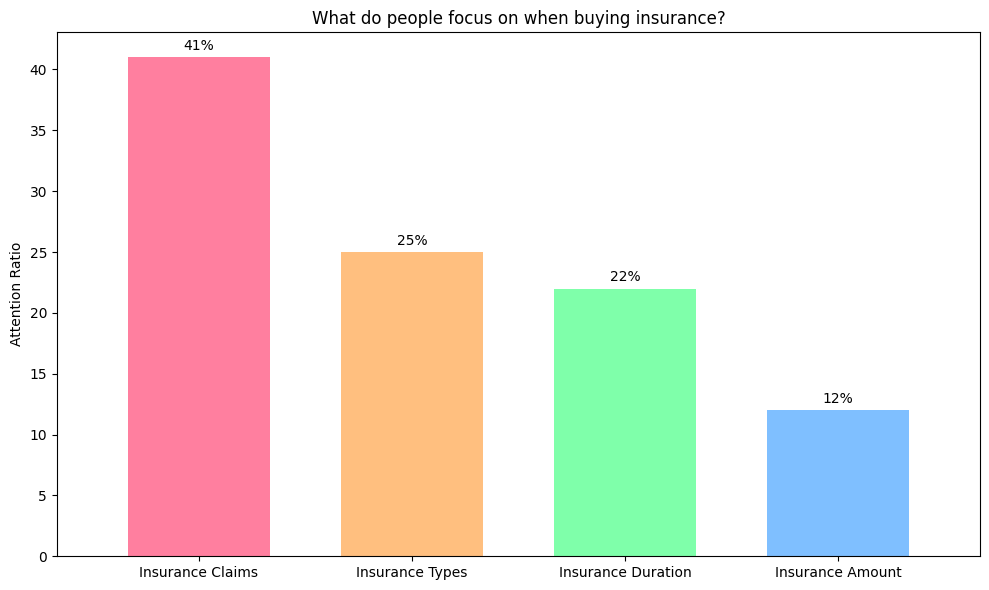

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['Insurance Claims', 'Insurance Types', 'Insurance Duration', 'Insurance Amount']
values = [41, 25, 22, 12]
colors = ['#ff7f9f', '#ffbf7f', '#7fffaa', '#7fbfff']  # 对应颜色

# 调整横坐标位置，增加间距
x = np.arange(len(labels)) * 1.2  # 扩大横坐标间距（原间距×1.2）

# 创建画布并适当增大宽度
fig, ax = plt.subplots(figsize=(10, 6))  # 加宽画布以容纳更宽的间距
rects = ax.bar(x, values, color=colors, width=0.8)  # 控制柱宽，避免过宽

# 添加数值标签
for rect in rects:
    height = rect.get_height()
    ax.annotate('{}%'.format(height),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 标签位置偏移
                textcoords="offset points",
                ha='center', va='bottom')

# 设置横坐标刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)  # 可适当减小字体
ax.set_ylabel('Attention Ratio')
ax.set_title('What do people focus on when buying insurance?')

# 调整x轴范围，避免两端标签贴近边缘
ax.set_xlim(x[0] - 0.8, x[-1] + 0.8)

plt.tight_layout()  # 自动调整布局
plt.show()